# Paragliding Thermal Heatmap — Arbas Site

**Pipeline:**
1. Load real SRTM elevation data
2. Run simplified thermal/wind simulation (numpy-based Boussinesq)
3. Export vector fields as JSON for Three.js

**Note:** FEniCS/DOLFINx is not yet installed. Phase 2 uses a numpy-based finite-difference solver.

## Phase 1 — Terrain Data

In [1]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from rasterio.merge import merge as rasterio_merge
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json
import os

# Arbas site bounding box (updated)
BBOX = {
    'min_lon': 0.8384807238737125,
    'max_lon': 0.933902446260169,
    'min_lat': 42.96106090862103,
    'max_lat': 43.014963556361636,
    'center_lat': 42.99565929402203,
    'center_lon': 0.9054050088740738
}

# Waypoints
LANDING  = {'lat': 42.99216012970225,  'lon': 0.9039819278411977,  'name': 'Landing'}
TAKEOFF  = {'lat': 42.96939867981149,  'lon': 0.8859389033562173,  'name': 'Take-off'}

print('Imports OK')
print(f'Bbox: {BBOX["min_lat"]:.4f}–{BBOX["max_lat"]:.4f}N, {BBOX["min_lon"]:.4f}–{BBOX["max_lon"]:.4f}E')

Imports OK
Bbox: 42.9611–43.0150N, 0.8385–0.9339E


In [2]:
def fetch_srtm_tile(min_lon, min_lat, max_lon, max_lat, output_path):
    """Download SRTM1 tiles (30m) and merge+clip to bounding box."""
    import requests, gzip, shutil

    lat_tiles = range(int(np.floor(min_lat)), int(np.floor(max_lat)) + 1)
    lon_tiles = range(int(np.floor(min_lon)), int(np.floor(max_lon)) + 1)

    hgt_paths = []
    for lat in lat_tiles:
        for lon in lon_tiles:
            lat_str = f'N{lat:02d}' if lat >= 0 else f'S{abs(lat):02d}'
            lon_str = f'E{lon:03d}' if lon >= 0 else f'W{abs(lon):03d}'
            url = (f'https://s3.amazonaws.com/elevation-tiles-prod/skadi/'
                   f'{lat_str}/{lat_str}{lon_str}.hgt.gz')
            cache_gz  = f'/tmp/{lat_str}{lon_str}.hgt.gz'
            cache_hgt = f'/tmp/{lat_str}{lon_str}.hgt'

            if not os.path.exists(cache_hgt):
                print(f'Downloading {lat_str}{lon_str}...')
                r = requests.get(url, timeout=60)
                r.raise_for_status()
                with open(cache_gz, 'wb') as f:
                    f.write(r.content)
                with gzip.open(cache_gz, 'rb') as gz, open(cache_hgt, 'wb') as hgt:
                    shutil.copyfileobj(gz, hgt)
            else:
                print(f'Using cached {lat_str}{lon_str}')
            hgt_paths.append(cache_hgt)

    # Open all tiles and merge, then clip
    datasets = [rasterio.open(p) for p in hgt_paths]
    if len(datasets) == 1:
        merged, merged_transform = datasets[0].read(1), datasets[0].transform
        src_crs = datasets[0].crs
        src_dtype = datasets[0].dtypes[0]
        datasets[0].close()
    else:
        merged_arr, merged_transform = rasterio_merge(datasets)
        merged = merged_arr[0]
        src_crs  = datasets[0].crs
        src_dtype = datasets[0].dtypes[0]
        for ds in datasets:
            ds.close()

    # Clip to bbox using a temporary in-memory dataset
    import io
    with rasterio.MemoryFile() as memfile:
        profile = {
            'driver': 'GTiff', 'dtype': src_dtype,
            'width': merged.shape[1], 'height': merged.shape[0],
            'count': 1, 'crs': src_crs, 'transform': merged_transform
        }
        with memfile.open(**profile) as mem:
            mem.write(merged, 1)
            window = from_bounds(min_lon, min_lat, max_lon, max_lat, mem.transform)
            elevation = mem.read(1, window=window).astype(np.float32)
            clip_transform = mem.window_transform(window)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    profile = {
        'driver': 'GTiff', 'dtype': 'float32',
        'width': elevation.shape[1], 'height': elevation.shape[0],
        'count': 1, 'crs': 'EPSG:4326', 'transform': clip_transform
    }
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(elevation, 1)

    return elevation, clip_transform


TIF_PATH = 'data/arbas_srtm.tif'

if not os.path.exists(TIF_PATH):
    elevation_raw, transform = fetch_srtm_tile(
        BBOX['min_lon'], BBOX['min_lat'], BBOX['max_lon'], BBOX['max_lat'], TIF_PATH
    )
    print(f'Fetched and saved to {TIF_PATH}')
else:
    print(f'Using cached {TIF_PATH}')

with rasterio.open(TIF_PATH) as src:
    elevation_raw = src.read(1).astype(np.float32)
    transform = src.transform
    crs = src.crs

print(f'Elevation shape: {elevation_raw.shape}')
print(f'Elevation range: {elevation_raw.min():.0f}m – {elevation_raw.max():.0f}m')
print(f'CRS: {crs}')

Using cached data/arbas_srtm.tif
Elevation shape: (194, 344)
Elevation range: 380m – 1592m
CRS: EPSG:4326


In [3]:
def latlon_to_local(lat, lon, lat0, lon0):
    """Convert lat/lon to local East/North meters (equirectangular)."""
    R = 6371000
    x = (lon - lon0) * np.cos(np.radians(lat0)) * R * np.pi / 180
    y = -(lat - lat0) * R * np.pi / 180  # flip: north is +Y
    return float(x), float(y)


def extract_3d_terrain(tif_path, sampling_step=1):
    """Convert GeoTIFF to structured X, Y, Z grids in meters (local frame)."""
    with rasterio.open(tif_path) as src:
        elevation = src.read(1, masked=True).astype(np.float32)
        t = src.transform

        rows, cols = np.mgrid[0:elevation.shape[0]:sampling_step,
                               0:elevation.shape[1]:sampling_step]
        lons = t.c + cols * t.a
        lats = t.f + rows * t.e
        z = elevation[::sampling_step, ::sampling_step]

        lat0 = float(lats.mean())
        lon0 = float(lons.mean())
        R = 6371000
        X = (lons - lon0) * np.cos(np.radians(lat0)) * R * np.pi / 180
        Y = -(lats - lat0) * R * np.pi / 180
        Z = np.array(z)

    return X, Y, Z, lons, lats, lat0, lon0


X, Y, Z, lons, lats, LAT0, LON0 = extract_3d_terrain(TIF_PATH)
print(f'3D terrain grid: {X.shape}')
print(f'Physical extent: X={X.min():.0f}–{X.max():.0f}m, Y={Y.min():.0f}–{Y.max():.0f}m')
print(f'Projection origin: lat={LAT0:.5f}, lon={LON0:.5f}')

# Compute waypoint local coords + terrain elevation under each
def elevation_at(lat, lon, elev_grid, lats_grid, lons_grid):
    iy = int(np.argmin(np.abs(lats_grid[:, 0] - lat)))
    ix = int(np.argmin(np.abs(lons_grid[0, :] - lon)))
    return float(elev_grid[iy, ix])

for wp in (LANDING, TAKEOFF):
    wx, wy = latlon_to_local(wp['lat'], wp['lon'], LAT0, LON0)
    wz = elevation_at(wp['lat'], wp['lon'], Z, lats, lons)
    wp['x'], wp['y'], wp['z'] = wx, wy, wz
    print(f"{wp['name']}: x={wx:.0f}m, y={wy:.0f}m, z={wz:.0f}m")

3D terrain grid: (194, 344)
Physical extent: X=-3875–3875m, Y=-2981–2981m
Projection origin: lat=42.98816, lon=0.88612
Landing: x=1453m, y=-445m, z=420m
Take-off: x=-15m, y=2086m, z=1108m


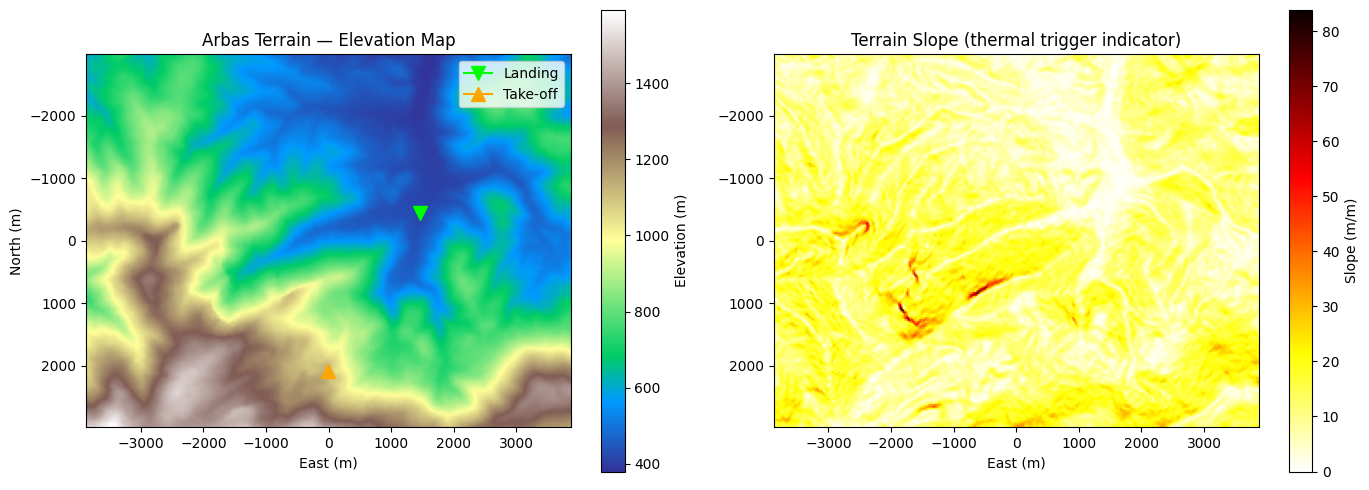

Saved data/terrain_visualization.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# With origin='upper', row 0 is at the top of the image (northernmost).
# extent=[left, right, bottom, top] — swap Y so top=Y.min (north), bottom=Y.max (south).
extent = [X.min(), X.max(), Y.max(), Y.min()]

im = axes[0].imshow(Z, cmap='terrain', origin='upper', extent=extent)
plt.colorbar(im, ax=axes[0], label='Elevation (m)')
axes[0].set_title('Arbas Terrain — Elevation Map')
axes[0].set_xlabel('East (m)'); axes[0].set_ylabel('North (m)')

for wp, color, marker in [(LANDING, 'lime', 'v'), (TAKEOFF, 'orange', '^')]:
    axes[0].plot(wp['x'], wp['y'], marker=marker, color=color, ms=10, label=wp['name'])
axes[0].legend()

dzdx = np.gradient(Z, axis=1)
dzdy = np.gradient(Z, axis=0)
slope = np.sqrt(dzdx**2 + dzdy**2)
im2 = axes[1].imshow(slope, cmap='hot_r', origin='upper', extent=extent)
plt.colorbar(im2, ax=axes[1], label='Slope (m/m)')
axes[1].set_title('Terrain Slope (thermal trigger indicator)')
axes[1].set_xlabel('East (m)')

plt.tight_layout()
plt.savefig('data/terrain_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved data/terrain_visualization.png')

## Phase 2 — Thermal Simulation (Numpy-based Boussinesq)

In [5]:
from scipy.ndimage import gaussian_filter, zoom

g = 9.81; beta = 0.0034; T0 = 293.15; rho0 = 1.2

SIM_NX = 64; SIM_NY = 32; SIM_NZ = 32; DOMAIN_H = 2000

scale_y = SIM_NY / Z.shape[0]
scale_x = SIM_NX / Z.shape[1]
Z_sim = zoom(Z, (scale_y, scale_x), order=1)
X_sim = np.linspace(X.min(), X.max(), SIM_NX)
Y_sim = np.linspace(Y.min(), Y.max(), SIM_NY)
dx = X_sim[1] - X_sim[0]
dy = Y_sim[1] - Y_sim[0]
Z_min = Z_sim.min(); Z_max = Z_sim.max()
dz = DOMAIN_H / SIM_NZ

print(f'Simulation grid: {SIM_NX}x{SIM_NY}x{SIM_NZ}')
print(f'Grid spacing: dx={dx:.1f}m, dy={dy:.1f}m, dz={dz:.1f}m')
print(f'Terrain elevation: {Z_min:.0f}m – {Z_max:.0f}m')

Simulation grid: 64x32x32
Grid spacing: dx=123.0m, dy=192.3m, dz=62.5m
Terrain elevation: 386m – 1587m


In [6]:
def compute_solar_heating(Z_grid, sun_azimuth_deg, sun_elevation_deg, max_heat=15.0):
    dzdx = np.gradient(Z_grid, axis=1)
    dzdy = np.gradient(Z_grid, axis=0)
    nx = -dzdx; ny = -dzdy; nz = np.ones_like(Z_grid)
    norm = np.sqrt(nx**2 + ny**2 + nz**2)
    nx, ny, nz = nx/norm, ny/norm, nz/norm
    az = np.radians(sun_azimuth_deg); el = np.radians(sun_elevation_deg)
    sx = np.sin(az) * np.cos(el); sy = np.cos(az) * np.cos(el); sz = np.sin(el)
    insolation = np.clip(nx*sx + ny*sy + nz*sz, 0, 1)
    insolation = gaussian_filter(insolation, sigma=1.5)
    return max_heat * insolation

dT_ground = compute_solar_heating(Z_sim, 180, 60)
print(f'dT range: {dT_ground.min():.1f} – {dT_ground.max():.1f} K')

dT range: 0.4 – 7.5 K


In [7]:
def compute_thermal_field(Z_grid, dT_ground):
    """Pure thermal updraft field — no background wind."""
    NX, NY, NZ = SIM_NX, SIM_NY, SIM_NZ
    u = np.zeros((NZ, NY, NX))
    v = np.zeros((NZ, NY, NX))
    w = np.zeros((NZ, NY, NX))
    z_levels = Z_min + (np.arange(NZ) + 0.5) * dz
    for k, z_k in enumerate(z_levels):
        above = z_k > Z_grid
        z_above = np.maximum(z_k - Z_grid, 0)
        decay = np.exp(-z_above / 500.0)
        buoyancy_w = np.clip(g * beta * dT_ground * decay * (z_above / (z_above + 100)), 0, 8.0)
        w[k] = buoyancy_w * above
        # Mass conservation: compensating sink where no strong thermal
        sink_mask = above & (buoyancy_w < 0.1)
        if sink_mask.sum() > 0:
            w[k][sink_mask] -= w[k].mean()
    w = gaussian_filter(w, sigma=[0.5, 1.5, 1.5])
    return u, v, w

u, v, w = compute_thermal_field(Z_sim, dT_ground)
print(f'Thermal field: w range {w.min():.2f} – {w.max():.2f} m/s')

Thermal field: w range -0.03 – 0.10 m/s


In [8]:
SCENARIOS = [
    {'name': 'morning',   'sun_az': 120, 'sun_el': 30},
    {'name': 'midday',    'sun_az': 180, 'sun_el': 65},
    {'name': 'afternoon', 'sun_az': 240, 'sun_el': 35},
    {'name': 'evening',   'sun_az': 280, 'sun_el': 15},
]

output = {
    'terrain': {
        'nx': SIM_NX, 'ny': SIM_NY, 'nz': SIM_NZ,
        'x_extent': [float(X_sim.min()), float(X_sim.max())],
        'y_extent': [float(Y_sim.min()), float(Y_sim.max())],
        'z_extent': [float(Z_min), float(Z_min + DOMAIN_H)],
        'dx': float(dx), 'dy': float(dy), 'dz': float(dz),
        'elevation': Z_sim.tolist(),
        'projection_origin': {'lat': LAT0, 'lon': LON0}
    },
    'markers': [
        {'name': LANDING['name'], 'type': 'landing',
         'x': LANDING['x'], 'y': LANDING['y'], 'z': LANDING['z']},
        {'name': TAKEOFF['name'], 'type': 'takeoff',
         'x': TAKEOFF['x'], 'y': TAKEOFF['y'], 'z': TAKEOFF['z']}
    ],
    'scenarios': []
}

for sc in SCENARIOS:
    print(f"Computing {sc['name']}...")
    dT = compute_solar_heating(Z_sim, sc['sun_az'], sc['sun_el'])
    u, v, w = compute_thermal_field(Z_sim, dT)
    step = 2
    output['scenarios'].append({
        'name': sc['name'],
        'sun_azimuth': sc['sun_az'], 'sun_elevation': sc['sun_el'],
        'ground_temp_anomaly': dT.tolist(),
        'u': u[::step].tolist(), 'v': v[::step].tolist(), 'w': w[::step].tolist(),
    })

os.makedirs('data', exist_ok=True)
with open('data/simulation.json', 'w') as f:
    json.dump(output, f)

size_mb = os.path.getsize('data/simulation.json') / 1e6
print(f'Saved data/simulation.json ({size_mb:.1f} MB) — {len(SCENARIOS)} scenarios')

Computing morning...
Computing midday...
Computing afternoon...
Computing evening...


Saved data/simulation.json (4.4 MB) — 4 scenarios


## Phase 3 — Export for Three.js

Serve from project root: `python -m http.server 8000` → open `web/index.html`